In [1]:
from google.colab import drive
drive.mount('/content/drive')

DatasetPath = "/content/drive/MyDrive/dataset/brain-tumor-mri-dataset"
Training_data_path = f"{DatasetPath}/Training"
Testing_data_path = f"{DatasetPath}/Testing"

Mounted at /content/drive


In [2]:
import tensorflow as tf

IMG_SIZE = (256, 256)
BATCH_SIZE = 32

Train_data = tf.keras.utils.image_dataset_from_directory(
    Training_data_path, image_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=True, seed=42
)
Test_data = tf.keras.utils.image_dataset_from_directory(
    Testing_data_path, image_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=False
)

class_names = Train_data.class_names
print(class_names)

AUTOTUNE = tf.data.AUTOTUNE
Train_data = Train_data.cache().shuffle(1000).prefetch(AUTOTUNE)
Test_data = Test_data.cache().prefetch(AUTOTUNE)

Found 5600 files belonging to 4 classes.
Found 1600 files belonging to 4 classes.
['glioma', 'meningioma', 'notumor', 'pituitary']


In [3]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.08),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1),
], name="data_augmentation")

In [4]:
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(256, 256, 3)
)
base_model.trainable = False  # freeze for phase 1

inputs = layers.Input(shape=(256, 256, 3))
x = data_augmentation(inputs)
x = preprocess_input(x)          # EfficientNet's own normalization — do NOT add Rescaling on top of this
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(4, activation="softmax")(x)

model_tl = Model(inputs, outputs, name="efficientnet_transfer")

model_tl.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_tl.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "efficientnet_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 8, 8, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,214,055 (16.08 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [5]:
checkpoint_tl = tf.keras.callbacks.ModelCheckpoint(
    filepath="best_model_transfer.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

early_stopping_tl = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=6,
    mode="max",
    restore_best_weights=True,
    verbose=1
)

reduce_lr_tl = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

In [6]:
history_phase1 = model_tl.fit(
    Train_data,
    validation_data=Test_data,
    epochs=15,
    callbacks=[checkpoint_tl, early_stopping_tl, reduce_lr_tl]
)

Epoch 1/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.6849 - loss: 0.7729
Epoch 1: val_accuracy improved from None to 0.78438, saving model to best_model_transfer.keras

Epoch 1: finished saving model to best_model_transfer.keras
175/175 ━━━━━━━━━━━━━━━━━━━━ 1977s 3s/step - accuracy: 0.7711 - loss: 0.5895 - val_accuracy: 0.7844 - val_loss: 0.6318 - learning_rate: 0.0010
Epoch 2/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.8453 - loss: 0.4015
Epoch 2: val_accuracy did not improve from 0.78438
175/175 ━━━━━━━━━━━━━━━━━━━━ 19s 111ms/step - accuracy: 0.8443 - loss: 0.4032 - val_accuracy: 0.7694 - val_loss: 0.6088 - learning_rate: 0.0010
Epoch 3/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.8516 - loss: 0.3866
Epoch 3: val_accuracy improved from 0.78438 to 0.83312, saving model to best_model_transfer.keras

Epoch 3: finished saving model to best_model_transfer.keras
175/175 ━━━━━━━━━━━━━━━━━━━━ 22s 124ms/step - accuracy: 0.8579 - loss: 0.3664 - val_ac

In [7]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

# Critical fix: keep BatchNorm layers frozen even among the unfrozen last 30
for layer in base_model.layers[-30:]:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

model_tl.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Sanity check — count how many BN layers got correctly re-frozen
bn_trainable = sum(1 for l in base_model.layers[-30:] if isinstance(l, tf.keras.layers.BatchNormalization) and l.trainable)
print(f"Trainable BatchNorm layers in fine-tune range: {bn_trainable}")  # should print 0

history_phase2 = model_tl.fit(
    Train_data,
    validation_data=Test_data,
    epochs=15,
    callbacks=[checkpoint_tl, early_stopping_tl, reduce_lr_tl]
)

Trainable BatchNorm layers in fine-tune range: 0
Epoch 1/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.9110 - loss: 0.2171
Epoch 1: val_accuracy did not improve from 0.86750
175/175 ━━━━━━━━━━━━━━━━━━━━ 39s 149ms/step - accuracy: 0.9146 - loss: 0.2214 - val_accuracy: 0.8581 - val_loss: 0.4426 - learning_rate: 1.0000e-05
Epoch 2/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.9165 - loss: 0.2073
Epoch 2: val_accuracy improved from 0.86750 to 0.87500, saving model to best_model_transfer.keras

Epoch 2: finished saving model to best_model_transfer.keras
175/175 ━━━━━━━━━━━━━━━━━━━━ 38s 133ms/step - accuracy: 0.9164 - loss: 0.2095 - val_accuracy: 0.8750 - val_loss: 0.4242 - learning_rate: 1.0000e-05
Epoch 3/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.9200 - loss: 0.2078
Epoch 3: val_accuracy did not improve from 0.87500
175/175 ━━━━━━━━━━━━━━━━━━━━ 22s 127ms/step - accuracy: 0.9237 - loss: 0.1992 - val_accuracy: 0.8719 - val_loss: 0.4276 - learning

              precision    recall  f1-score   support

      glioma       0.95      0.72      0.82       400
  meningioma       0.83      0.83      0.83       400
     notumor       0.93      0.99      0.96       400
   pituitary       0.85      0.99      0.92       400

    accuracy                           0.89      1600
   macro avg       0.89      0.89      0.88      1600
weighted avg       0.89      0.89      0.88      1600



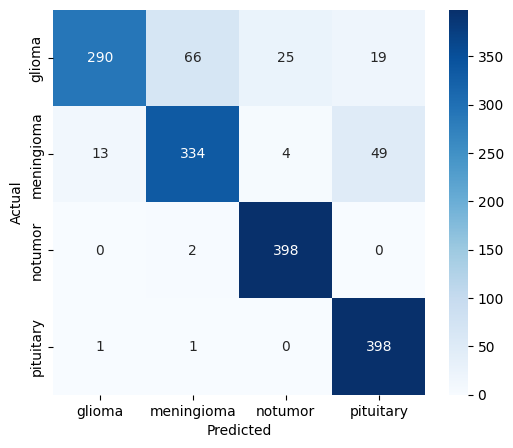

In [8]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_true, y_pred = [], []
for images, labels in Test_data:
    preds = model_tl.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names, cmap="Blues")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.show()

In [9]:
checkpoint_tl = tf.keras.callbacks.ModelCheckpoint(
    filepath="/content/drive/MyDrive/models/Best_transferLearning.keras",  # writes directly to Drive
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

In [13]:
model_tl.save(f"{DatasetPath}/best_model.keras")